# Zero Density in Symmetric-Group Character Tables

This notebook plots the density of zero entries in character tables of `S_n`.

- Small values of `n` are computed directly with `murnaghan_nakayama.get_character_table`.
- Larger available tables such as `S_39` and `S_40` are computed by streaming CSV or gzip-compressed CSV files, so the full tables are never loaded into memory.
- Zero density means `number of zero entries / total number of entries`.


In [28]:
from pathlib import Path
import csv
import gzip
import time

import matplotlib.pyplot as plt
import numpy as np

import murnaghan_nakayama as mn

## Configuration

Increase `SMALL_N_MAX` if your machine can compute more direct tables. Larger available CSV files, including `S_39` and `S_40`, are streamed from disk instead of loaded into memory. The notebook looks for those files directly under the repository root first.


In [29]:
SMALL_N_MAX = 25
INCLUDE_S39 = True
INCLUDE_S40 = True
S39_CANDIDATES = [
    Path("S39.csv.gz"),
    Path("S39.csv"),
    Path("runs/S39/S39.csv.gz"),
    Path("runs/S39/S39.csv"),
]
S40_CANDIDATES = [
    Path("S40.csv.gz"),
    Path("S40.csv"),
    Path("runs/S40/S40.csv.gz"),
    Path("runs/S40/S40.csv"),
]
CSV_PROGRESS_INTERVAL = 1000
HEATMAP_BINS = 800
HEATMAP_PROGRESS_INTERVAL = 1000


## Helper functions

In [30]:
def open_text_maybe_gzip(path):
    if str(path).endswith(".gz"):
        return gzip.open(path, "rt", newline="")
    return open(path, "r", newline="")


def zero_density_array(table):
    zero_count = int(np.count_nonzero(table == 0))
    total_count = int(table.size)
    return {
        "zero_count": zero_count,
        "total_count": total_count,
        "density": zero_count / total_count,
    }


def zero_density_csv(path, expected_size=None, progress_interval=1000):
    path = Path(path)
    zero_count = 0
    total_count = 0
    rows = 0
    width = None
    start = time.perf_counter()

    with open_text_maybe_gzip(path) as file:
        reader = csv.reader(file)
        for row in reader:
            rows += 1
            if width is None:
                width = len(row)
            elif len(row) != width:
                raise ValueError(
                    f"Ragged row {rows}: expected {width} columns, found {len(row)}"
                )

            total_count += len(row)
            zero_count += sum(1 for value in row if value.strip() == "0")

            if progress_interval and rows % progress_interval == 0:
                elapsed = time.perf_counter() - start
                if expected_size:
                    percent = 100 * rows / expected_size
                    print(
                        f"{path.name}: {rows}/{expected_size} rows "
                        f"({percent:.1f}%), elapsed {elapsed:.1f}s"
                    )
                else:
                    print(f"{path.name}: {rows} rows, elapsed {elapsed:.1f}s")

    if expected_size is not None and rows != expected_size:
        raise ValueError(f"Expected {expected_size} rows, found {rows}")
    if expected_size is not None and width != expected_size:
        raise ValueError(f"Expected {expected_size} columns, found {width}")

    elapsed = time.perf_counter() - start
    return {
        "zero_count": zero_count,
        "total_count": total_count,
        "density": zero_count / total_count,
        "rows": rows,
        "columns": width,
        "elapsed_seconds": elapsed,
        "path": str(path),
    }


def find_first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    return None


def zero_heatmap_blocks_csv(path, expected_size, bins=800, progress_interval=1000):
    path = Path(path)
    zero_counts = np.zeros((bins, bins), dtype=np.uint64)
    row_bin_sizes = np.zeros(bins, dtype=np.uint64)
    col_bin_sizes = np.zeros(bins, dtype=np.uint64)
    col_bins = np.array(
        [min(col * bins // expected_size, bins - 1) for col in range(expected_size)],
        dtype=np.int32,
    )
    for col_bin in col_bins:
        col_bin_sizes[col_bin] += 1

    rows = 0
    width = None
    start = time.perf_counter()
    with open_text_maybe_gzip(path) as file:
        reader = csv.reader(file)
        for row in reader:
            rows += 1
            if width is None:
                width = len(row)
                if width != expected_size:
                    raise ValueError(f"Expected {expected_size} columns, found {width}")
            elif len(row) != width:
                raise ValueError(
                    f"Ragged row {rows}: expected {width} columns, found {len(row)}"
                )

            row_bin = min((rows - 1) * bins // expected_size, bins - 1)
            row_bin_sizes[row_bin] += 1
            for value, col_bin in zip(row, col_bins):
                if value.strip() == "0":
                    zero_counts[row_bin, col_bin] += 1

            if progress_interval and rows % progress_interval == 0:
                elapsed = time.perf_counter() - start
                percent = 100 * rows / expected_size
                print(
                    f"{path.name} heatmap: {rows}/{expected_size} rows "
                    f"({percent:.1f}%), elapsed {elapsed:.1f}s"
                )

    if rows != expected_size:
        raise ValueError(f"Expected {expected_size} rows, found {rows}")

    block_sizes = np.outer(row_bin_sizes, col_bin_sizes)
    zero_density = np.divide(
        zero_counts,
        block_sizes,
        out=np.zeros_like(zero_counts, dtype=np.float64),
        where=block_sizes != 0,
    )
    elapsed = time.perf_counter() - start
    return {
        "zero_density": zero_density,
        "zero_counts": zero_counts,
        "block_sizes": block_sizes,
        "rows": rows,
        "columns": width,
        "elapsed_seconds": elapsed,
        "path": str(path),
        "bins": bins,
    }


def append_streamed_density(results, n, candidates, progress_interval=1000):
    table_path = find_first_existing(candidates)
    if table_path is None:
        print(f"Skipping S_{n}: no file found at", [str(path) for path in candidates])
        return results

    expected_size = len(list(mn.partitions(n)))
    print(f"Streaming {table_path} with expected shape {expected_size} x {expected_size}")
    stats = zero_density_csv(
        table_path,
        expected_size=expected_size,
        progress_interval=progress_interval,
    )
    results = [result for result in results if result["n"] != n]
    results.append({"n": n, "source": "csv", **stats})
    print(
        f"S_{n}: zeros={stats['zero_count']}/{stats['total_count']}, "
        f"density={stats['density']:.6f}, elapsed={stats['elapsed_seconds']:.2f}s"
    )
    return results


## Compute densities for directly computed `n`

These tables are computed directly. With `SMALL_N_MAX = 14`, this gives a denser set of points before the streamed `S_40` value. The row and column ordering does not affect zero density.


In [31]:
results = []

for n in range(1, SMALL_N_MAX + 1):
    start = time.perf_counter()
    mn.clear_caches()
    table = mn.get_character_table(n, memo_file_name="")
    stats = zero_density_array(table)
    elapsed = time.perf_counter() - start
    results.append({"n": n, "source": "computed", "elapsed_seconds": elapsed, **stats})
    print(
        f"S_{n}: p(n)={table.shape[0]}, zeros={stats['zero_count']}/"
        f"{stats['total_count']}, density={stats['density']:.6f}, elapsed={elapsed:.2f}s"
    )

S_1: p(n)=1, zeros=0/1, density=0.000000, elapsed=8.84s
S_2: p(n)=2, zeros=0/4, density=0.000000, elapsed=0.00s
S_3: p(n)=3, zeros=1/9, density=0.111111, elapsed=0.00s
S_4: p(n)=5, zeros=4/25, density=0.160000, elapsed=0.00s
S_5: p(n)=7, zeros=10/49, density=0.204082, elapsed=0.00s
S_6: p(n)=11, zeros=29/121, density=0.239669, elapsed=0.00s
S_7: p(n)=15, zeros=55/225, density=0.244444, elapsed=0.00s
S_8: p(n)=22, zeros=153/484, density=0.316116, elapsed=0.00s
S_9: p(n)=30, zeros=307/900, density=0.341111, elapsed=0.01s
S_10: p(n)=42, zeros=588/1764, density=0.333333, elapsed=0.01s
S_11: p(n)=56, zeros=1018/3136, density=0.324617, elapsed=0.02s
S_12: p(n)=77, zeros=2230/5929, density=0.376117, elapsed=0.04s
S_13: p(n)=101, zeros=3543/10201, density=0.347319, elapsed=0.06s
S_14: p(n)=135, zeros=6878/18225, density=0.377394, elapsed=0.33s
S_15: p(n)=176, zeros=11216/30976, density=0.362087, elapsed=0.36s
S_16: p(n)=231, zeros=20615/53361, density=0.386331, elapsed=0.43s
S_17: p(n)=297, ze

## Stream the `S_39` table

This cell reads an available `S_39` CSV or gzip-compressed CSV one row at a time and appends its zero density to the results.


In [32]:
if INCLUDE_S39:
    results = append_streamed_density(
        results,
        39,
        S39_CANDIDATES,
        progress_interval=CSV_PROGRESS_INTERVAL,
    )


Streaming S39.csv with expected shape 31185 x 31185
S39.csv: 1000/31185 rows (3.2%), elapsed 6.1s
S39.csv: 2000/31185 rows (6.4%), elapsed 11.2s
S39.csv: 3000/31185 rows (9.6%), elapsed 17.7s
S39.csv: 4000/31185 rows (12.8%), elapsed 25.1s
S39.csv: 5000/31185 rows (16.0%), elapsed 32.5s
S39.csv: 6000/31185 rows (19.2%), elapsed 41.2s
S39.csv: 7000/31185 rows (22.4%), elapsed 49.7s
S39.csv: 8000/31185 rows (25.7%), elapsed 61.4s
S39.csv: 9000/31185 rows (28.9%), elapsed 71.5s
S39.csv: 10000/31185 rows (32.1%), elapsed 79.4s
S39.csv: 11000/31185 rows (35.3%), elapsed 86.5s
S39.csv: 12000/31185 rows (38.5%), elapsed 94.3s
S39.csv: 13000/31185 rows (41.7%), elapsed 98.8s
S39.csv: 14000/31185 rows (44.9%), elapsed 103.0s
S39.csv: 15000/31185 rows (48.1%), elapsed 107.2s
S39.csv: 16000/31185 rows (51.3%), elapsed 112.3s
S39.csv: 17000/31185 rows (54.5%), elapsed 116.6s
S39.csv: 18000/31185 rows (57.7%), elapsed 121.1s
S39.csv: 19000/31185 rows (60.9%), elapsed 125.3s
S39.csv: 20000/31185 row

## Stream the `S_40` table

This cell reads the large CSV one row at a time. It supports either the raw CSV or the gzip-compressed CSV.

In [33]:
if INCLUDE_S40:
    results = append_streamed_density(
        results,
        40,
        S40_CANDIDATES,
        progress_interval=CSV_PROGRESS_INTERVAL,
    )


Streaming S40.csv with expected shape 37338 x 37338
S40.csv: 1000/37338 rows (2.7%), elapsed 5.6s
S40.csv: 2000/37338 rows (5.4%), elapsed 11.2s
S40.csv: 3000/37338 rows (8.0%), elapsed 16.6s
S40.csv: 4000/37338 rows (10.7%), elapsed 22.5s
S40.csv: 5000/37338 rows (13.4%), elapsed 28.8s
S40.csv: 6000/37338 rows (16.1%), elapsed 34.4s
S40.csv: 7000/37338 rows (18.7%), elapsed 39.7s
S40.csv: 8000/37338 rows (21.4%), elapsed 45.9s
S40.csv: 9000/37338 rows (24.1%), elapsed 53.7s
S40.csv: 10000/37338 rows (26.8%), elapsed 60.6s
S40.csv: 11000/37338 rows (29.5%), elapsed 67.6s
S40.csv: 12000/37338 rows (32.1%), elapsed 74.6s
S40.csv: 13000/37338 rows (34.8%), elapsed 84.8s
S40.csv: 14000/37338 rows (37.5%), elapsed 95.5s
S40.csv: 15000/37338 rows (40.2%), elapsed 106.6s
S40.csv: 16000/37338 rows (42.9%), elapsed 122.0s
S40.csv: 17000/37338 rows (45.5%), elapsed 134.3s
S40.csv: 18000/37338 rows (48.2%), elapsed 141.7s
S40.csv: 19000/37338 rows (50.9%), elapsed 149.6s
S40.csv: 20000/37338 rows

## Plot zero density

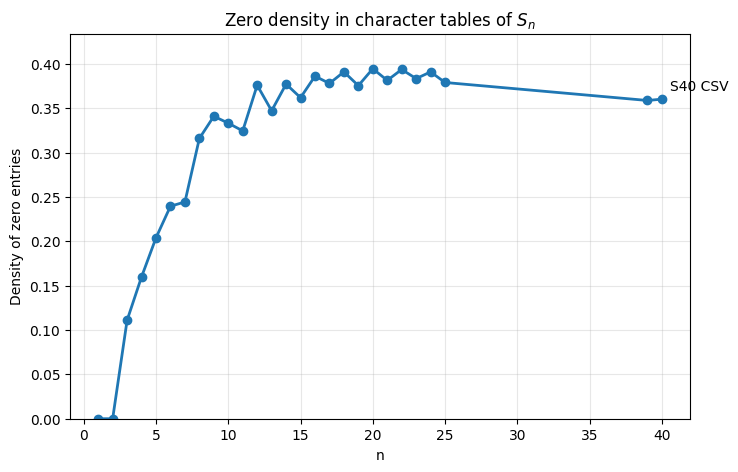

In [34]:
plot_results = sorted(results, key=lambda item: item["n"])
xs = [item["n"] for item in plot_results]
ys = [item["density"] for item in plot_results]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, ys, marker="o", linewidth=2)
ax.set_xlabel("n")
ax.set_ylabel("Density of zero entries")
ax.set_title("Zero density in character tables of $S_n$")
ax.set_ylim(0, max(ys) * 1.1 if ys else 1)
ax.grid(True, alpha=0.3)

for item in plot_results:
    label = "S40 CSV" if item["n"] == 40 and item.get("source") == "csv" else None
    if label:
        ax.annotate(label, (item["n"], item["density"]), xytext=(6, 6), textcoords="offset points")

plt.show()

## S_40 zero-pattern heatmap

This is a block-downsampled heatmap of the zero pattern. Each pixel shows the fraction of entries equal to zero in a block of the full `S_40` table. Bright cells are zero-heavy. This avoids storing a literal 37,338 by 37,338 image in memory.


In [ ]:
s40_heatmap = None
if INCLUDE_S40:
    s40_path = find_first_existing(S40_CANDIDATES)
    if s40_path is None:
        print("Skipping S_40 heatmap: no file found at", [str(path) for path in S40_CANDIDATES])
    else:
        expected_size = len(list(mn.partitions(40)))
        print(
            f"Building {HEATMAP_BINS} x {HEATMAP_BINS} zero-density heatmap "
            f"from {s40_path}"
        )
        s40_heatmap = zero_heatmap_blocks_csv(
            s40_path,
            expected_size=expected_size,
            bins=HEATMAP_BINS,
            progress_interval=HEATMAP_PROGRESS_INTERVAL,
        )
        print(
            f"Finished heatmap in {s40_heatmap['elapsed_seconds']:.2f}s; "
            f"shape={s40_heatmap['zero_density'].shape}"
        )


Building 800 x 800 zero-density heatmap from S40.csv
S40.csv heatmap: 1000/37338 rows (2.7%), elapsed 16.3s


## Plot S_40 zero-pattern heatmap


In [ ]:
if s40_heatmap is None:
    print("Run the heatmap cell above after placing S40.csv or S40.csv.gz in the repo root.")
else:
    fig, ax = plt.subplots(figsize=(9, 8))
    image = ax.imshow(
        s39_heatmap["zero_density"],
        origin="upper",
        interpolation="nearest",
        cmap="magma",
        vmin=0,
        vmax=1,
    )
    ax.set_title("Zero pattern heatmap for $S_{39}$")
    ax.set_xlabel("Conjugacy class index block")
    ax.set_ylabel("Irreducible representation index block")
    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label("Fraction of entries equal to 0")
    plt.tight_layout()
    plt.show()


## Data table

In [ ]:
for item in plot_results:
    print(
        f"n={item['n']:>2} source={item['source']:<8} "
        f"zero_density={item['density']:.8f} "
        f"zeros={item['zero_count']} total={item['total_count']}"
    )